In [5]:
import pandas as pd
import jax
from arviz.labels import MapLabeller

import sys
import os
sys.path.append(os.path.abspath(os.path.join('../..')))

from utils.modeling import (
    encode_categorical_covariates, 
    fit_model_and_extract_idata,
    pairwise_logistic_model,
    )

from utils.plotting import (
    plot_predictive_distributions,
    plot_combined_figure_binomial,
    plot_model_comparison
)

# Get data

In [6]:
df = pd.read_csv('data.csv')
# Check
print('Unique graders:', set(df['grader']))
df.head(5)

Unique graders: {'Autograder', 'Human'}


,LLM_1,LLM_2,grader,first_is_chosen,length_diff,llm_pair
0,LLM A,LLM B,Human,0,110.667705,LLM A-LLM B
1,LLM A,LLM B,Human,0,37.495431,LLM A-LLM B
2,LLM A,LLM B,Human,1,127.349066,LLM A-LLM B
3,LLM A,LLM B,Human,1,61.091630,LLM A-LLM B
4,LLM A,LLM B,Human,0,99.146100,LLM A-LLM B


# Fit model

In [7]:
# Define covariates and outcome
main_effects = ['llm_pair', 'grader', 'length_diff']
interactions = []
outcome = 'first_is_chosen'  # first LLM in the pair is chosen

# Encode categorical covariates
covariates_dict, category_maps = encode_categorical_covariates(df, main_effects)

# Continuous covariates
numeric_col = 'length_diff'
covariates_dict[numeric_col] = ( (df[numeric_col] - df[numeric_col].mean()) / df[numeric_col].std() ).to_numpy(dtype="float32")

# Outcome
y = df[outcome].values

# Fit model
rng_key = jax.random.PRNGKey(0)

mcmc_length, idata_length = fit_model_and_extract_idata( 
    rng_key, 
    covariates_dict, 
    y, 
    main_effects = ['llm_pair', 'grader', 'length_diff'], 
    interactions = [], 
    category_maps = category_maps, 
    model = pairwise_logistic_model)


mcmc_no_length, idata_no_length = fit_model_and_extract_idata( 
    rng_key, 
    covariates_dict, 
    y, 
    main_effects = ['llm_pair', 'grader'], 
    interactions = [], 
    category_maps = category_maps, 
    model = pairwise_logistic_model)

sample: 100%|██████████| 2000/2000 [00:02<00:00, 762.40it/s, 7 steps of size 1.05e-01. acc. prob=0.91]  


# Fitted parameters

In [8]:
mcmc_length.print_summary()


                                   mean       std    median      5.0%     95.0%     n_eff     r_hat
             b_grader_full[0]      0.69      0.67      0.70     -0.34      1.74    408.28      1.00
             b_grader_full[1]     -0.22      0.66     -0.21     -1.25      0.79    407.07      1.00
b_grader_length_slope_full[0]      1.39      0.23      1.39      0.96      1.72    851.10      1.00
b_grader_length_slope_full[1]     -0.24      0.18     -0.24     -0.53      0.05    845.22      1.00
           b_llm_pair_full[0]      0.66      0.53      0.66     -0.24      1.48    411.42      1.00
           b_llm_pair_full[1]      0.60      0.51      0.61     -0.20      1.45    370.69      1.00
           b_llm_pair_full[2]     -0.69      0.57     -0.72     -1.57      0.26    418.21      1.00
                    intercept      0.49      0.67      0.47     -0.58      1.60    403.62      1.00
            length_slope_mean      0.20      0.40      0.20     -0.43      0.87    790.89      1.00

# Model comparison

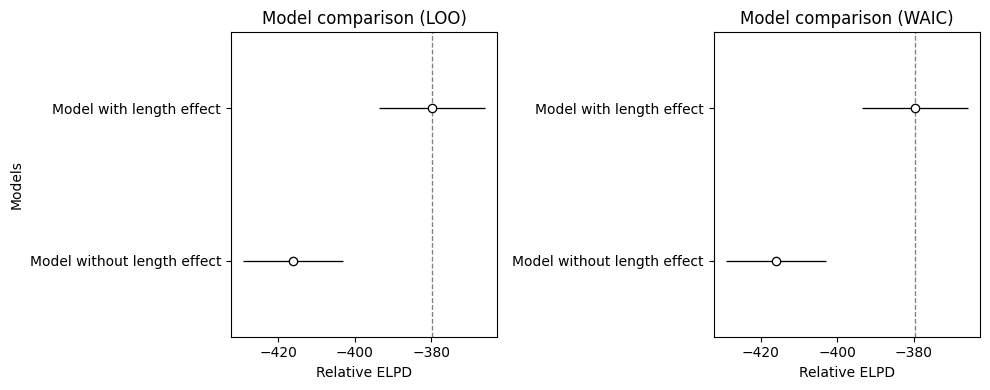

In [9]:
idata_dict = {
    "Model with length effect": mcmc_length,
    "Model without length effect": mcmc_no_length
}

plot_model_comparison(idata_dict, ylabel="Models", fig_path="../../figures/figure6c.png")

## Checks

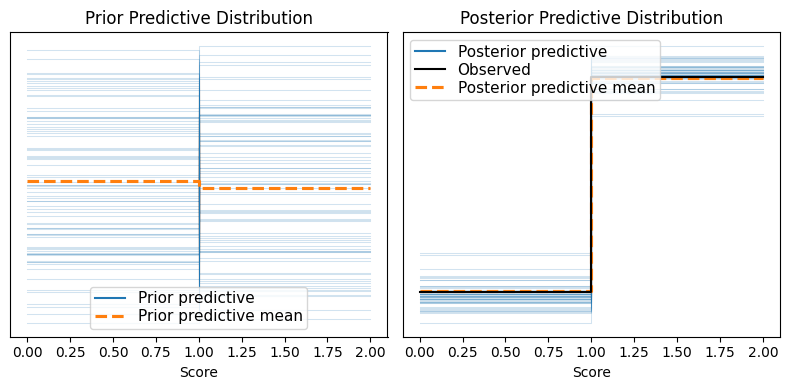

In [10]:
plot_predictive_distributions(idata_length, fig_path="fig_predictive.png")

# Figure

In [ ]:
labeller = MapLabeller(
    var_name_map={
        "b_grader_length_slope_full": "Grader length bias",
        "length_slope_mean": "Average length bias",
        "b_grader_full": "Grader effect",
        "b_llm_pair_full": "Pair effect",
    }
)

plot_combined_figure_binomial(df, idata_length, 
                     var_names=["b_grader_full", "b_llm_pair_full", "b_grader_length_slope_full", "length_slope_mean"],
                     labeller=labeller,
                     color_scheme='1autograder',
                     fig_path="../../figures/figure6.png",
                     legend_title=None,
                     xlim=[-2.5, 2.5],
                     vertical_centering=False,
                     show_predictions=False,
                     category_maps=category_maps,
                     jitter_strength=0.15
                     )

In [ ]:
# TODO
# Check if we need to report other things in the overleaf, e.g,, what the average length is, give the hierachy, the priors etc